In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from warnings import filterwarnings
filterwarnings("ignore")

In [2]:
train_data=pd.read_csv(r"C:\Users\yigit\OneDrive\Masaüstü\yapayzeka\data\train.csv")
test_data=pd.read_csv(r"C:\Users\yigit\OneDrive\Masaüstü\yapayzeka\data\test.csv")

In [3]:
train_data.head()

,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


In [4]:
all_data=pd.concat((train_data.loc[:,"Gender":"satisfaction"],
                    test_data.loc[:,"Gender":"satisfaction"]))

In [5]:
all_data.isnull().sum()

Gender                                 0
Customer Type                          0
Age                                    0
Type of Travel                         0
Class                                  0
Flight Distance                        0
Inflight wifi service                  0
Departure/Arrival time convenient      0
Ease of Online booking                 0
Gate location                          0
Food and drink                         0
Online boarding                        0
Seat comfort                           0
Inflight entertainment                 0
On-board service                       0
Leg room service                       0
Baggage handling                       0
Checkin service                        0
Inflight service                       0
Cleanliness                            0
Departure Delay in Minutes             0
Arrival Delay in Minutes             393
satisfaction                           0
dtype: int64

In [6]:
print(all_data["Arrival Delay in Minutes"].isnull().sum()/all_data.shape[0]*100)

0.3025870033877425


In [7]:
all_data["Arrival Delay in Minutes"]=all_data["Arrival Delay in Minutes"].fillna(all_data["Arrival Delay in Minutes"].median())  

In [8]:
all_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 129880 entries, 0 to 25975
Data columns (total 23 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Gender                             129880 non-null  object 
 1   Customer Type                      129880 non-null  object 
 2   Age                                129880 non-null  int64  
 3   Type of Travel                     129880 non-null  object 
 4   Class                              129880 non-null  object 
 5   Flight Distance                    129880 non-null  int64  
 6   Inflight wifi service              129880 non-null  int64  
 7   Departure/Arrival time convenient  129880 non-null  int64  
 8   Ease of Online booking             129880 non-null  int64  
 9   Gate location                      129880 non-null  int64  
 10  Food and drink                     129880 non-null  int64  
 11  Online boarding                    129880 non

In [9]:
all_data.isnull().sum()

Gender                               0
Customer Type                        0
Age                                  0
Type of Travel                       0
Class                                0
Flight Distance                      0
Inflight wifi service                0
Departure/Arrival time convenient    0
Ease of Online booking               0
Gate location                        0
Food and drink                       0
Online boarding                      0
Seat comfort                         0
Inflight entertainment               0
On-board service                     0
Leg room service                     0
Baggage handling                     0
Checkin service                      0
Inflight service                     0
Cleanliness                          0
Departure Delay in Minutes           0
Arrival Delay in Minutes             0
satisfaction                         0
dtype: int64

In [10]:
numeric_cols=all_data.select_dtypes(include=["int64","float64"]).columns
numeric_cols

Index(['Age', 'Flight Distance', 'Inflight wifi service',
       'Departure/Arrival time convenient', 'Ease of Online booking',
       'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort',
       'Inflight entertainment', 'On-board service', 'Leg room service',
       'Baggage handling', 'Checkin service', 'Inflight service',
       'Cleanliness', 'Departure Delay in Minutes',
       'Arrival Delay in Minutes'],
      dtype='object')

(0.0, 90.0)

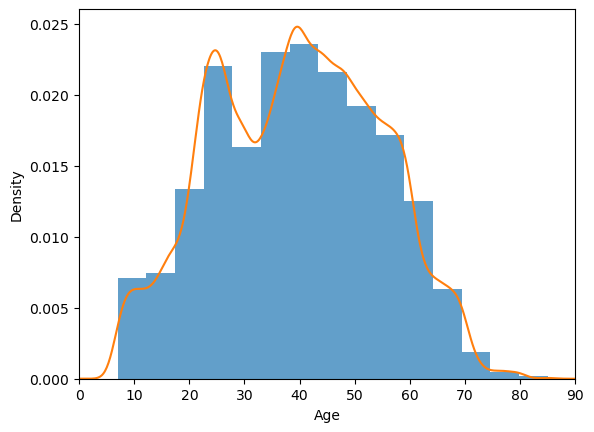

In [11]:
ax=all_data["Age"].hist(bins=15,density=True,stacked=True,alpha=0.7)
all_data["Age"].plot(kind="density")
ax.set(xlabel="Age")
plt.xlim(0,90)


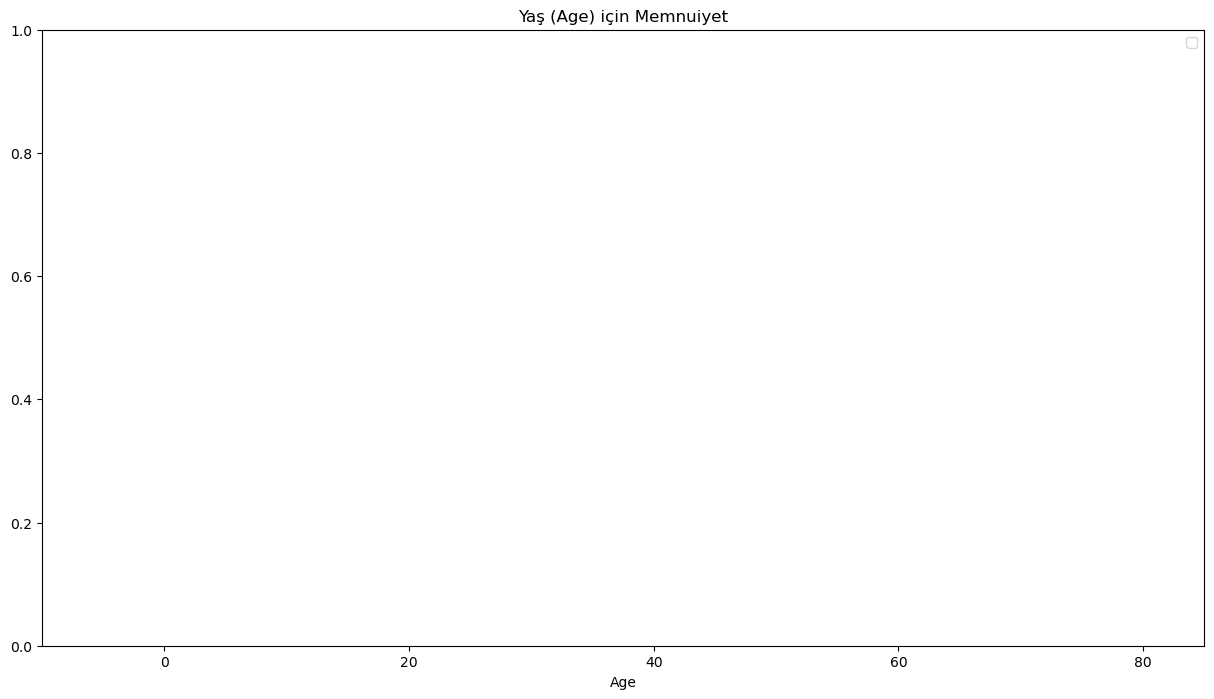

In [12]:
plt.figure(figsize=(15,8))
ax = sns.kdeplot(all_data["Age"][all_data.satisfaction == 1], color="green", shade=True)
sns.kdeplot(all_data["Age"][all_data.satisfaction == 0], color="red", shade=True)


plt.legend(['satisfied', 'neutral or dissatisfied'])
plt.title('Yaş (Age) için Memnuiyet')
ax.set(xlabel='Age')
plt.xlim(-10,85)
plt.show()

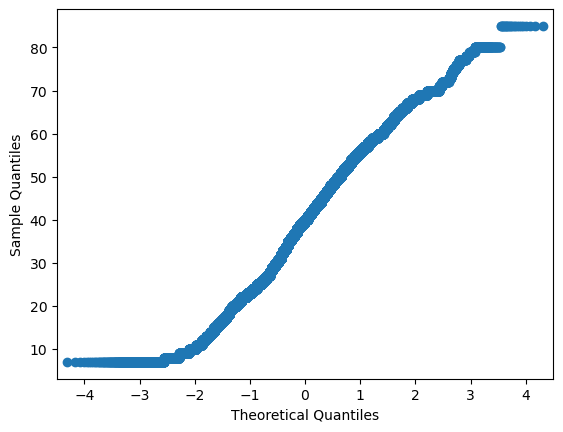

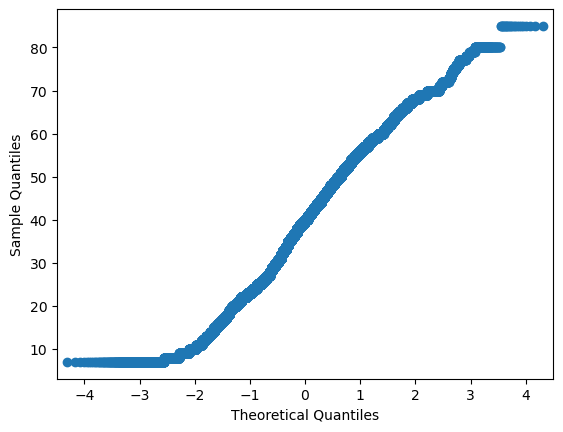

In [13]:
import statsmodels.api as sm

sm.qqplot(all_data["Age"])

In [14]:
cat_cols=all_data.select_dtypes(include="object").columns

array([[<Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'Flight Distance'}>,
        <Axes: title={'center': 'Inflight wifi service'}>,
        <Axes: title={'center': 'Departure/Arrival time convenient'}>],
       [<Axes: title={'center': 'Ease of Online booking'}>,
        <Axes: title={'center': 'Gate location'}>,
        <Axes: title={'center': 'Food and drink'}>,
        <Axes: title={'center': 'Online boarding'}>],
       [<Axes: title={'center': 'Seat comfort'}>,
        <Axes: title={'center': 'Inflight entertainment'}>,
        <Axes: title={'center': 'On-board service'}>,
        <Axes: title={'center': 'Leg room service'}>],
       [<Axes: title={'center': 'Baggage handling'}>,
        <Axes: title={'center': 'Checkin service'}>,
        <Axes: title={'center': 'Inflight service'}>,
        <Axes: title={'center': 'Cleanliness'}>],
       [<Axes: title={'center': 'Departure Delay in Minutes'}>,
        <Axes: title={'center': 'Arrival Delay in Minutes'}>, <A

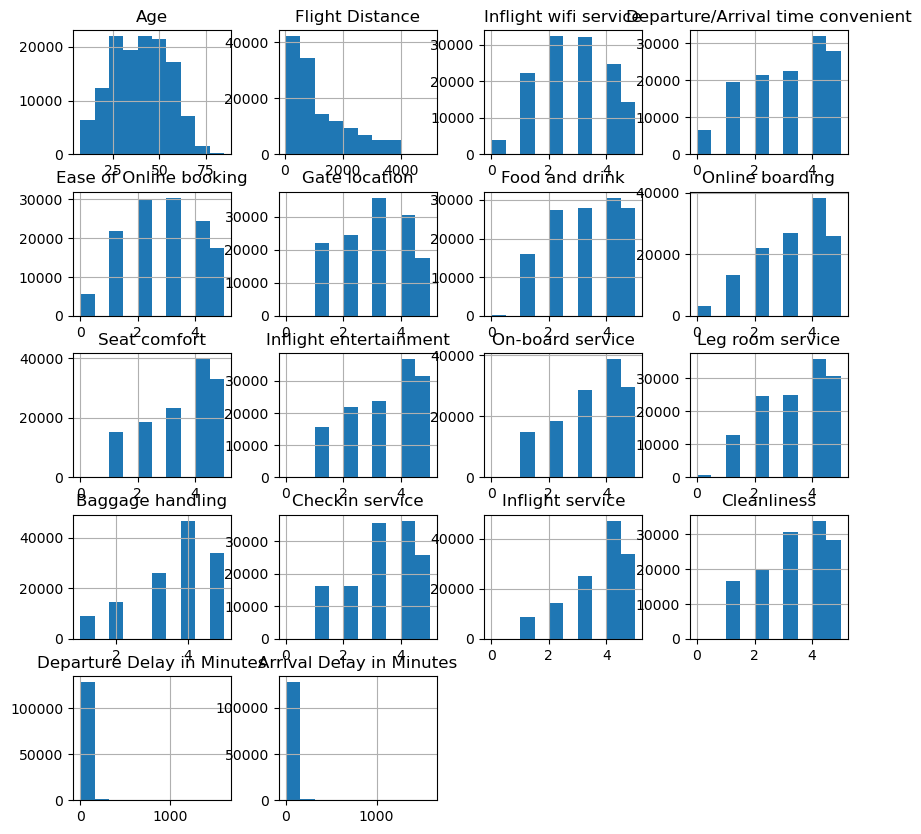

In [15]:
all_data.hist(column=numeric_cols,figsize=(10,10))

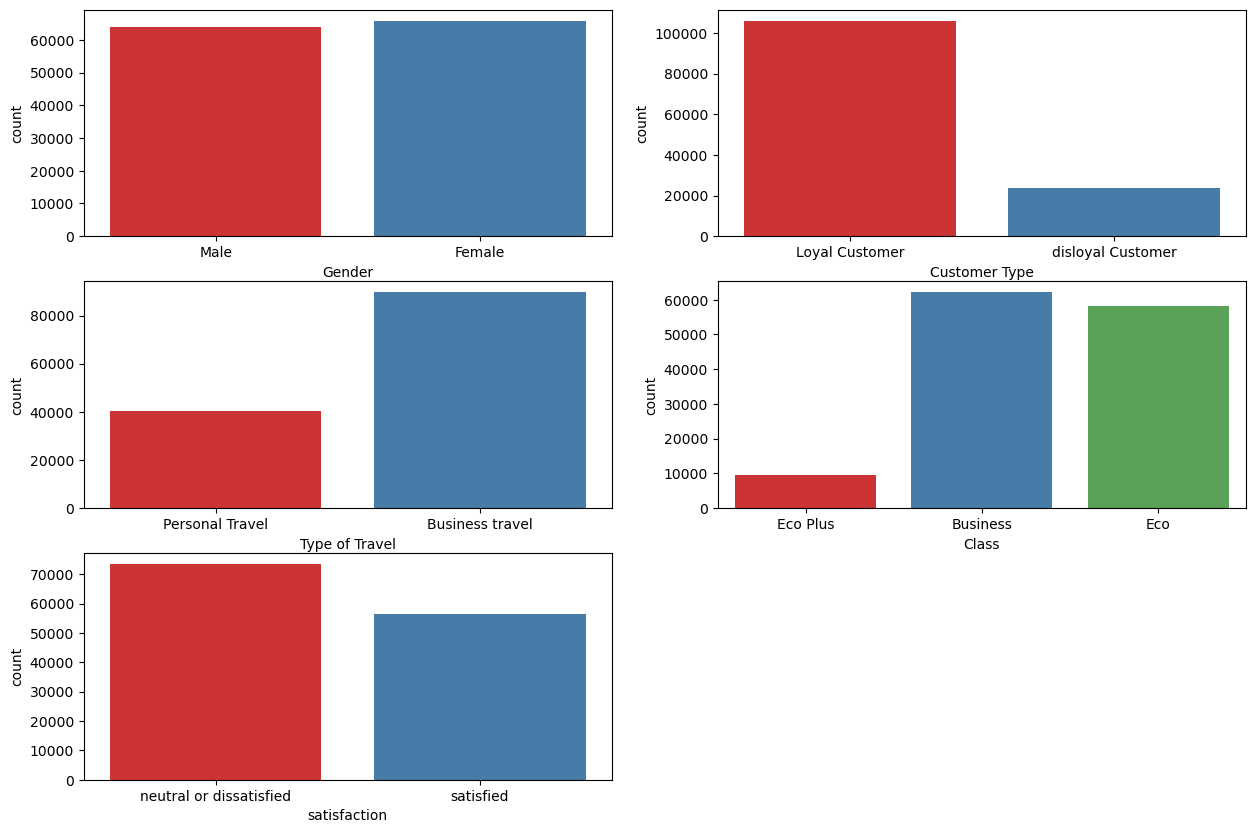

In [16]:
fig=plt.figure(figsize=(15,10))
for i in range(len(cat_cols)):
    plt.subplot(3,2,i+1)
    sns.countplot(x=all_data[cat_cols[i]],palette="Set1",data=all_data)
  

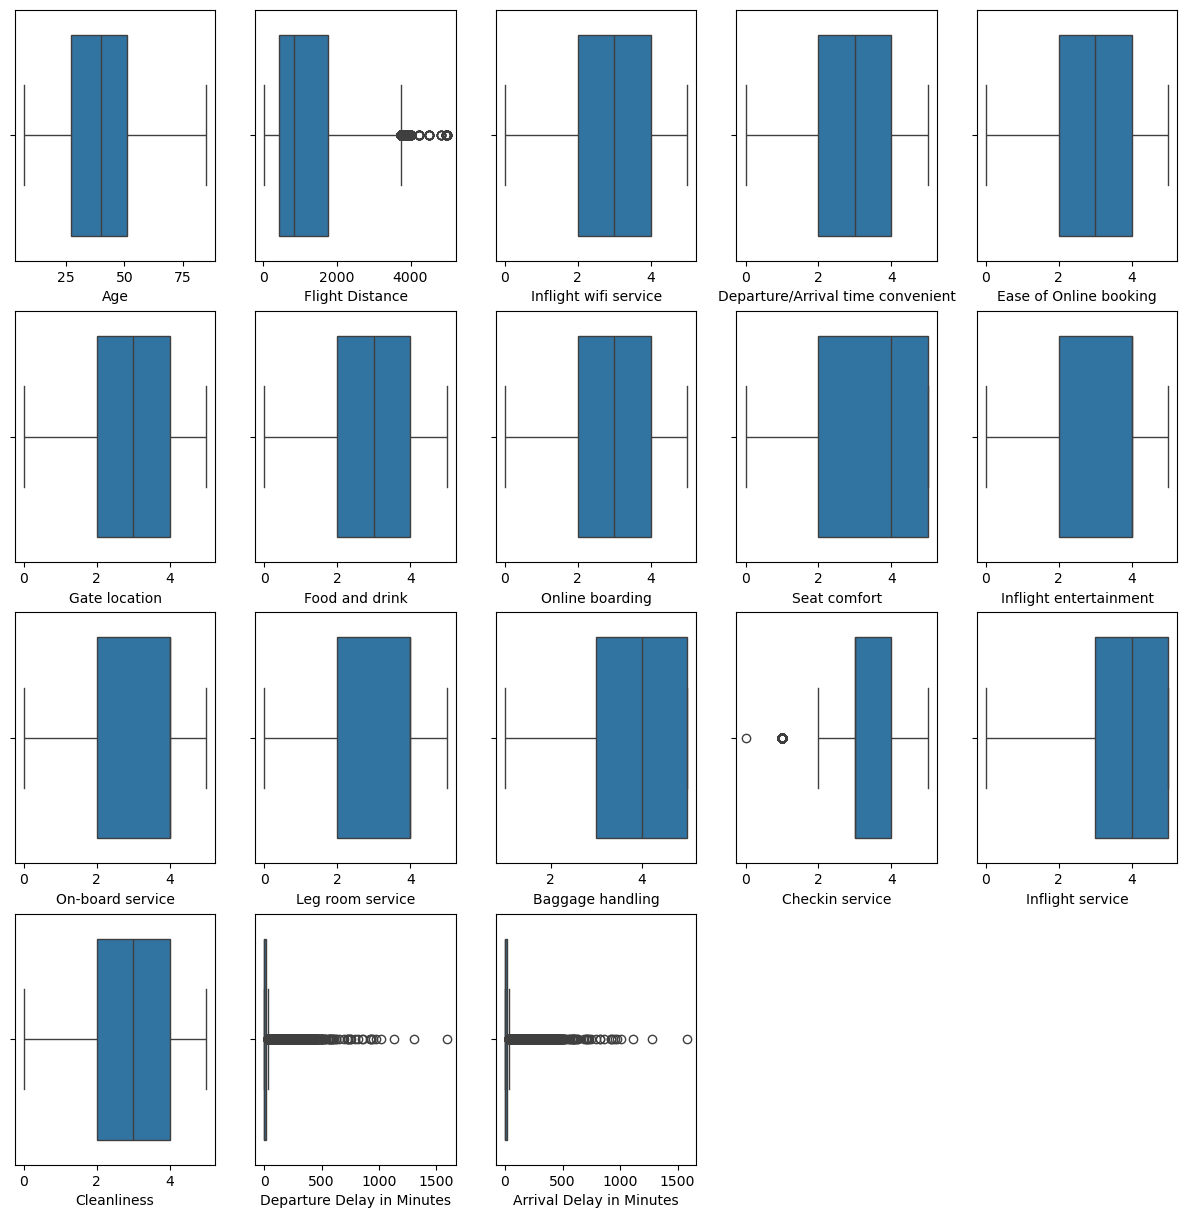

In [17]:
fig=plt.figure(figsize=(15,15))
for i in range(len(numeric_cols)):
    plt.subplot(4,5,i+1)
    sns.boxplot(x=all_data[numeric_cols[i]])

In [18]:
all_data.head()

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3,1,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,Male,disloyal Customer,25,Business travel,Business,235,3,2,3,3,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,Female,Loyal Customer,25,Business travel,Business,562,2,5,5,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,Male,Loyal Customer,61,Business travel,Business,214,3,3,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


In [19]:
from sklearn.preprocessing import LabelEncoder,OneHotEncoder

In [20]:
label_Encoder=LabelEncoder()
all_data["satisfaction"]=label_Encoder.fit_transform(all_data["satisfaction"].str.strip())
print(all_data["satisfaction"].unique())

[0 1]


In [21]:
all_data.head()

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3,1,...,5,4,3,4,4,5,5,25,18.0,0
1,Male,disloyal Customer,25,Business travel,Business,235,3,2,3,3,...,1,1,5,3,1,4,1,1,6.0,0
2,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2,2,...,5,4,3,4,4,4,5,0,0.0,1
3,Female,Loyal Customer,25,Business travel,Business,562,2,5,5,5,...,2,2,5,3,1,4,2,11,9.0,0
4,Male,Loyal Customer,61,Business travel,Business,214,3,3,3,3,...,3,3,4,4,3,3,3,0,0.0,1


In [22]:
all_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 129880 entries, 0 to 25975
Data columns (total 23 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Gender                             129880 non-null  object 
 1   Customer Type                      129880 non-null  object 
 2   Age                                129880 non-null  int64  
 3   Type of Travel                     129880 non-null  object 
 4   Class                              129880 non-null  object 
 5   Flight Distance                    129880 non-null  int64  
 6   Inflight wifi service              129880 non-null  int64  
 7   Departure/Arrival time convenient  129880 non-null  int64  
 8   Ease of Online booking             129880 non-null  int64  
 9   Gate location                      129880 non-null  int64  
 10  Food and drink                     129880 non-null  int64  
 11  Online boarding                    129880 non

In [23]:
columns=["Gender","Customer Type","Type of Travel","Class"]
for i in columns:
    all_data[i]=label_Encoder.fit_transform(all_data[i].str.strip())

In [24]:
all_data.head()

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,1,0,13,1,2,460,3,4,3,1,...,5,4,3,4,4,5,5,25,18.0,0
1,1,1,25,0,0,235,3,2,3,3,...,1,1,5,3,1,4,1,1,6.0,0
2,0,0,26,0,0,1142,2,2,2,2,...,5,4,3,4,4,4,5,0,0.0,1
3,0,0,25,0,0,562,2,5,5,5,...,2,2,5,3,1,4,2,11,9.0,0
4,1,0,61,0,0,214,3,3,3,3,...,3,3,4,4,3,3,3,0,0.0,1


In [25]:
all_data.columns

Index(['Gender', 'Customer Type', 'Age', 'Type of Travel', 'Class',
       'Flight Distance', 'Inflight wifi service',
       'Departure/Arrival time convenient', 'Ease of Online booking',
       'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort',
       'Inflight entertainment', 'On-board service', 'Leg room service',
       'Baggage handling', 'Checkin service', 'Inflight service',
       'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes',
       'satisfaction'],
      dtype='object')

In [26]:
from sklearn.preprocessing import MinMaxScaler
minmax_scaler=MinMaxScaler()
X_raw = all_data.drop("satisfaction", axis=1)
y = all_data["satisfaction"]

minmax_scaler = MinMaxScaler()
x= pd.DataFrame(minmax_scaler.fit_transform(X_raw), columns=X_raw.columns)


In [27]:
from sklearn.model_selection import train_test_split
x_Train,x_Test,y_Train,y_Test=train_test_split(x,y,test_size=0.3,random_state=42)

In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
logreg=LogisticRegression(max_iter=1000)
logreg.fit(x_Train,y_Train)
y_pred=logreg.predict(x_Test)

y_train_pred=logreg.predict(x_Train)
y_test_pred=logreg.predict(x_Test)
print("train accuracy:",accuracy_score(y_Train,y_train_pred))
print("test accuracy:",accuracy_score(y_Test,y_test_pred))

train accuracy: 0.874367548066347
test accuracy: 0.8747048557642952


In [29]:
from sklearn.metrics import classification_report
metric=classification_report(y_Test,y_pred)
print(metric)

              precision    recall  f1-score   support

           0       0.88      0.90      0.89     21979
           1       0.87      0.84      0.85     16985

    accuracy                           0.87     38964
   macro avg       0.87      0.87      0.87     38964
weighted avg       0.87      0.87      0.87     38964



In [30]:
from sklearn.metrics import  roc_auc_score,confusion_matrix
print("roc_auc score:%",roc_auc_score(y_Test,y_pred)*100)
print("confussin matrix",confusion_matrix(y_Test,y_pred))
print(roc_auc_score(y_Test,logreg.predict_proba(x_Test)[:,1]))


roc_auc score:% 87.04316667622744
confussin matrix [[19864  2115]
 [ 2767 14218]]
0.925798987373381


In [31]:
import statsmodels.api as sm
x_train_ols=sm.add_constant(x_Train)

In [32]:
x_train_ols = x_train_ols.reset_index(drop=True)
y_Train = y_Train.reset_index(drop=True)
sm_model=sm.OLS(y_Train,x_train_ols)
sonuc=sm_model.fit()

In [33]:
print(sonuc.summary())

                            OLS Regression Results                            
Dep. Variable:           satisfaction   R-squared:                       0.551
Model:                            OLS   Adj. R-squared:                  0.551
Method:                 Least Squares   F-statistic:                     5072.
Date:                Mon, 27 Apr 2026   Prob (F-statistic):               0.00
Time:                        22:34:47   Log-Likelihood:                -28775.
No. Observations:               90916   AIC:                         5.760e+04
Df Residuals:                   90893   BIC:                         5.781e+04
Df Model:                          22                                         
Covariance Type:            nonrobust                                         
                                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
const 

In [34]:
features_lg = x_Train.columns.tolist()  # hangi feature'larla eğittiysen
import pickle
pickle.dump({
    "model": logreg,
    "scaler": minmax_scaler,
    "features": features_lg  # ← sadece bu modelin kullandığı feature'lar
}, open("model_lg.pkl", "wb"))

In [35]:
import pickle
loaded = pickle.load(open(r"C:\Users\yigit\OneDrive\Masaüstü\yapayzeka\model_lg.pkl", "rb"))
print("Scaler n_features:", loaded["scaler"].n_features_in_)
print("Model n_features:", loaded["model"].n_features_in_)

# Bir test tahmini yap
import pandas as pd
test_input = {
    "Gender": 1, "Customer Type": 1, "Age": 35, "Type of Travel": 0, "Class": 0,
    "Flight Distance": 1000, "Inflight wifi service": 5,
    "Departure/Arrival time convenient": 5, "Ease of Online booking": 5,
    "Gate location": 5, "Food and drink": 5, "Online boarding": 5,
    "Seat comfort": 5, "Inflight entertainment": 5, "On-board service": 5,
    "Leg room service": 5, "Baggage handling": 5, "Checkin service": 5,
    "Inflight service": 5, "Cleanliness": 5,
    "Departure Delay in Minutes": 0, "Arrival Delay in Minutes": 0
}
df = pd.DataFrame([test_input])
X_scaled = loaded["scaler"].transform(df[loaded["features"]])
pred = loaded["model"].predict(X_scaled)
print("Tahmin:", "SATISFIED" if pred[0] == 1 else "NOT SATISFIED")

Scaler n_features: 22
Model n_features: 22
Tahmin: SATISFIED
